#### Notebook Setup

In [8]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import glob

PROJECT_ROOT = Path("/content/drive/MyDrive/DAT255/voice-command-assistant")

metrics_dir = PROJECT_ROOT/"results/metrics"

print("Metrics dir:", metrics_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Metrics dir: /content/drive/MyDrive/DAT255/voice-command-assistant/results/metrics


# Notebook 08 — Final Results Packaging

This notebook collects the final artifacts of the project.

Goals:
- Aggregate all experiment metrics
- Create final comparison tables
- Prepare figures for the report
- Prepare files for deployment and GitHub repository

## 1. Find all metrics files

In [9]:
metric_files = sorted(glob.glob(str(metrics_dir/"*_metrics.csv")))

print("Found metrics files:")
for f in metric_files:
    print(Path(f).name)

Found metrics files:
cnn_4class_baseline_1772452765_metrics.csv
cnn_5class_E1_downsample_1772911102_metrics.csv
cnn_5class_E2_downsample_aug_1772914070_metrics.csv
cnn_5class_weighted_1772453499_metrics.csv
raw_waveform_conv1d_1772920921_metrics.csv


#### Kombiner metrics

In [10]:
dfs = []

for f in metric_files:
    df = pd.read_csv(f)
    df["file"] = Path(f).name
    dfs.append(df)

metrics_all = pd.concat(dfs, ignore_index=True)

metrics_all

,run_name,n_params,best_val_acc,val_acc,val_macro_f1,test_acc,test_macro_f1,file,best_epoch,gpu_latency_ms,cpu_latency_ms
0,cnn_4class_baseline_1772452765,23780.0,0.847986,0.847986,0.844339,0.839035,0.834473,cnn_4class_baseline_1772452765_metrics.csv,NaN,NaN,NaN
1,cnn_5class_E1_downsample_1772911102,NaN,NaN,0.753657,0.587105,0.690593,0.685833,cnn_5class_E1_downsample_1772911102_metrics.csv,NaN,NaN,NaN
2,cnn_5class_E2_downsample_aug_1772914070,NaN,0.854037,0.854037,0.656390,0.783845,0.706706,cnn_5class_E2_downsample_aug_1772914070_metric...,6.0,NaN,NaN
3,cnn_5class_weighted_1772453499,23845.0,0.891019,0.891019,0.673565,0.748580,0.636543,cnn_5class_weighted_1772453499_metrics.csv,NaN,NaN,NaN
4,raw_waveform_conv1d_1772920921,9621.0,0.876277,0.876277,0.497388,0.709202,0.451925,raw_waveform_conv1d_1772920921_metrics.csv,9.0,0.629204,0.836143


#### Select important columns

In [11]:
cols = [
    "run_name",
    "n_params",
    "best_val_acc",
    "val_acc",
    "val_macro_f1",
    "test_acc",
    "test_macro_f1",
    "gpu_latency_ms",
    "cpu_latency_ms",
]

metrics_summary = metrics_all[[c for c in cols if c in metrics_all.columns]]

metrics_summary

,run_name,n_params,best_val_acc,val_acc,val_macro_f1,test_acc,test_macro_f1,gpu_latency_ms,cpu_latency_ms
0,cnn_4class_baseline_1772452765,23780.0,0.847986,0.847986,0.844339,0.839035,0.834473,NaN,NaN
1,cnn_5class_E1_downsample_1772911102,NaN,NaN,0.753657,0.587105,0.690593,0.685833,NaN,NaN
2,cnn_5class_E2_downsample_aug_1772914070,NaN,0.854037,0.854037,0.656390,0.783845,0.706706,NaN,NaN
3,cnn_5class_weighted_1772453499,23845.0,0.891019,0.891019,0.673565,0.748580,0.636543,NaN,NaN
4,raw_waveform_conv1d_1772920921,9621.0,0.876277,0.876277,0.497388,0.709202,0.451925,0.629204,0.836143


#### Create final comparison table

In [12]:
metrics_summary_sorted = metrics_summary.sort_values(
    by="test_macro_f1", ascending=False
)

metrics_summary_sorted

,run_name,n_params,best_val_acc,val_acc,val_macro_f1,test_acc,test_macro_f1,gpu_latency_ms,cpu_latency_ms
0,cnn_4class_baseline_1772452765,23780.0,0.847986,0.847986,0.844339,0.839035,0.834473,NaN,NaN
2,cnn_5class_E2_downsample_aug_1772914070,NaN,0.854037,0.854037,0.656390,0.783845,0.706706,NaN,NaN
1,cnn_5class_E1_downsample_1772911102,NaN,NaN,0.753657,0.587105,0.690593,0.685833,NaN,NaN
3,cnn_5class_weighted_1772453499,23845.0,0.891019,0.891019,0.673565,0.748580,0.636543,NaN,NaN
4,raw_waveform_conv1d_1772920921,9621.0,0.876277,0.876277,0.497388,0.709202,0.451925,0.629204,0.836143


#### Lagre final table

In [13]:
final_table_path = metrics_dir/"FINAL_model_comparison_table.csv"

metrics_summary_sorted.to_csv(final_table_path, index=False)

print("Saved:", final_table_path)

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/results/metrics/FINAL_model_comparison_table.csv


## 2. Collect Report Figures

#### Find figure directory

In [14]:
fig_dir = PROJECT_ROOT/"results/figures"

print("Figure directory:", fig_dir)

Figure directory: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures


#### List all figures

In [15]:
import glob

figure_files = sorted(glob.glob(str(fig_dir/"*.png")))

print("Found figures:")
for f in figure_files:
    print(Path(f).name)

Found figures:
aug_melspectrogram_example_0603.png
aug_waveform_original_vs_aug_0603.png
cnn_4class_baseline_1772452765_cm_test_0303.png
cnn_4class_baseline_1772452765_cm_val_0303.png
cnn_5class_weighted_1772453499_cm_test_0305.png
cnn_5class_weighted_1772453499_cm_val_0305.png
confusion_matrix_5class_E1_0602.png
confusion_matrix_5class_E2_downsample_aug_0604.png
confusion_matrix_raw_waveform_conv1d_0703.png
label_distribution_train_0104.png
mel_spectrogram_example_0202.png
train_dist_5class_unknown_downsample_12000_0601.png
waveform_example_0202.png


#### Make a figure table

In [16]:
fig_table = pd.DataFrame({
    "figure_file": [Path(f).name for f in figure_files],
    "path": figure_files
})

fig_table

,figure_file,path
0,aug_melspectrogram_example_0603.png,/content/drive/MyDrive/DAT255/voice-command-as...
1,aug_waveform_original_vs_aug_0603.png,/content/drive/MyDrive/DAT255/voice-command-as...
2,cnn_4class_baseline_1772452765_cm_test_0303.png,/content/drive/MyDrive/DAT255/voice-command-as...
3,cnn_4class_baseline_1772452765_cm_val_0303.png,/content/drive/MyDrive/DAT255/voice-command-as...
4,cnn_5class_weighted_1772453499_cm_test_0305.png,/content/drive/MyDrive/DAT255/voice-command-as...
5,cnn_5class_weighted_1772453499_cm_val_0305.png,/content/drive/MyDrive/DAT255/voice-command-as...
6,confusion_matrix_5class_E1_0602.png,/content/drive/MyDrive/DAT255/voice-command-as...
7,confusion_matrix_5class_E2_downsample_aug_0604...,/content/drive/MyDrive/DAT255/voice-command-as...
8,confusion_matrix_raw_waveform_conv1d_0703.png,/content/drive/MyDrive/DAT255/voice-command-as...
9,label_distribution_train_0104.png,/content/drive/MyDrive/DAT255/voice-command-as...


#### Save figure index

In [17]:
figure_index_path = PROJECT_ROOT/"results/figures/FIGURE_INDEX.csv"

fig_table.to_csv(figure_index_path, index=False)

print("Saved figure index:", figure_index_path)

Saved figure index: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/FIGURE_INDEX.csv


#### Preview figures

aug_melspectrogram_example_0603.png


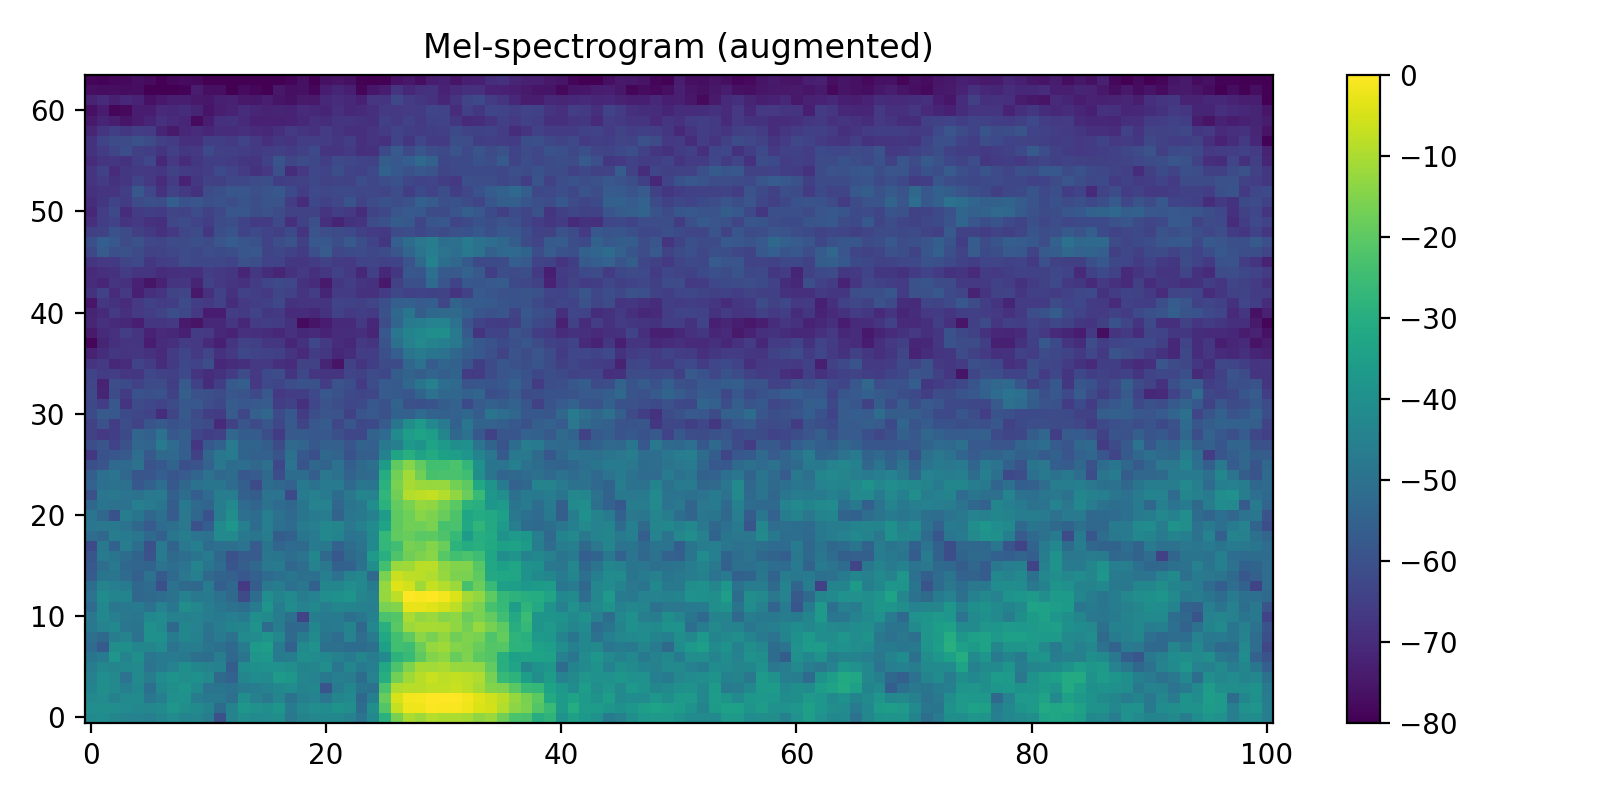

aug_waveform_original_vs_aug_0603.png


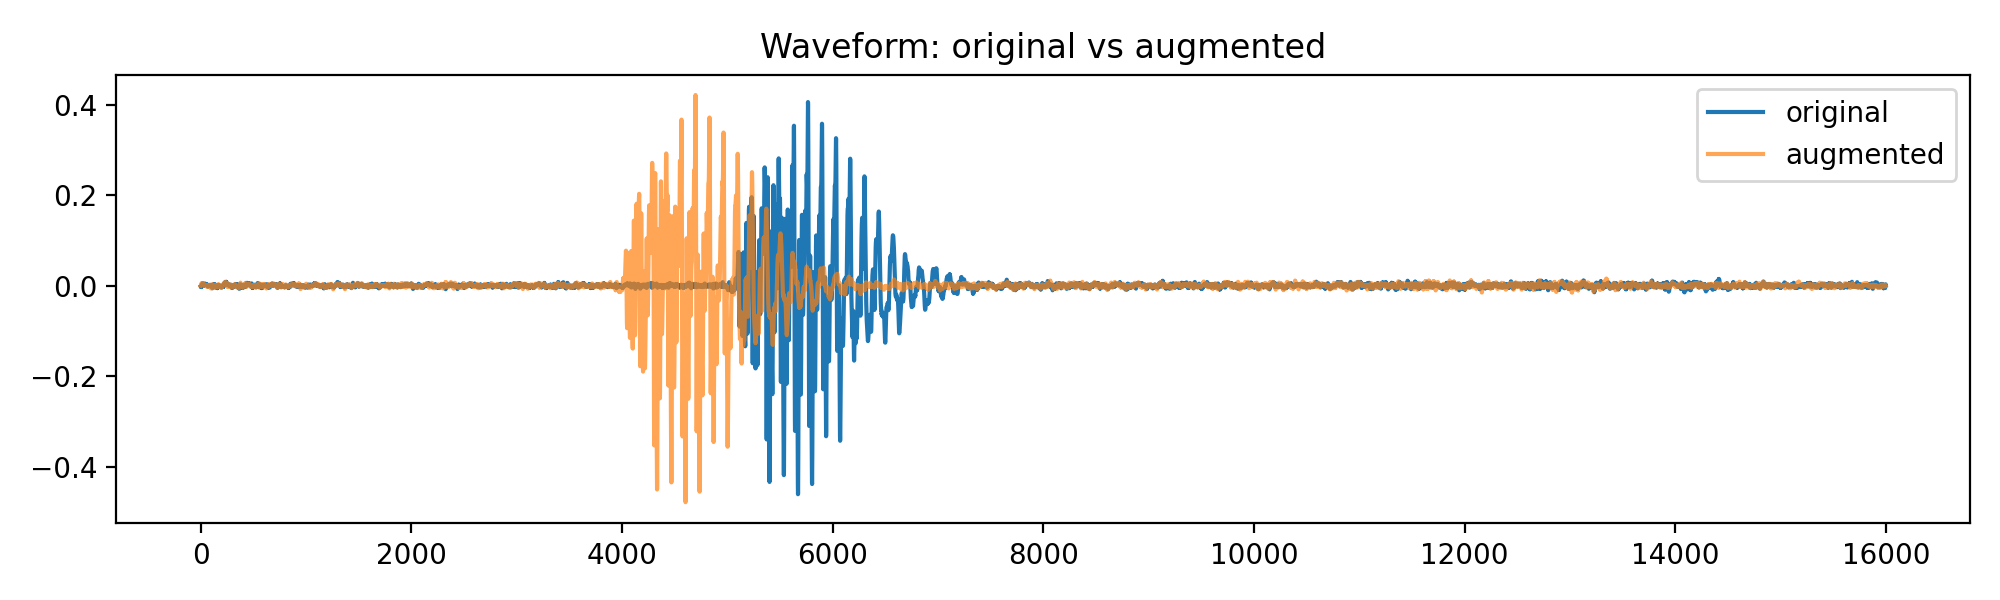

cnn_4class_baseline_1772452765_cm_test_0303.png


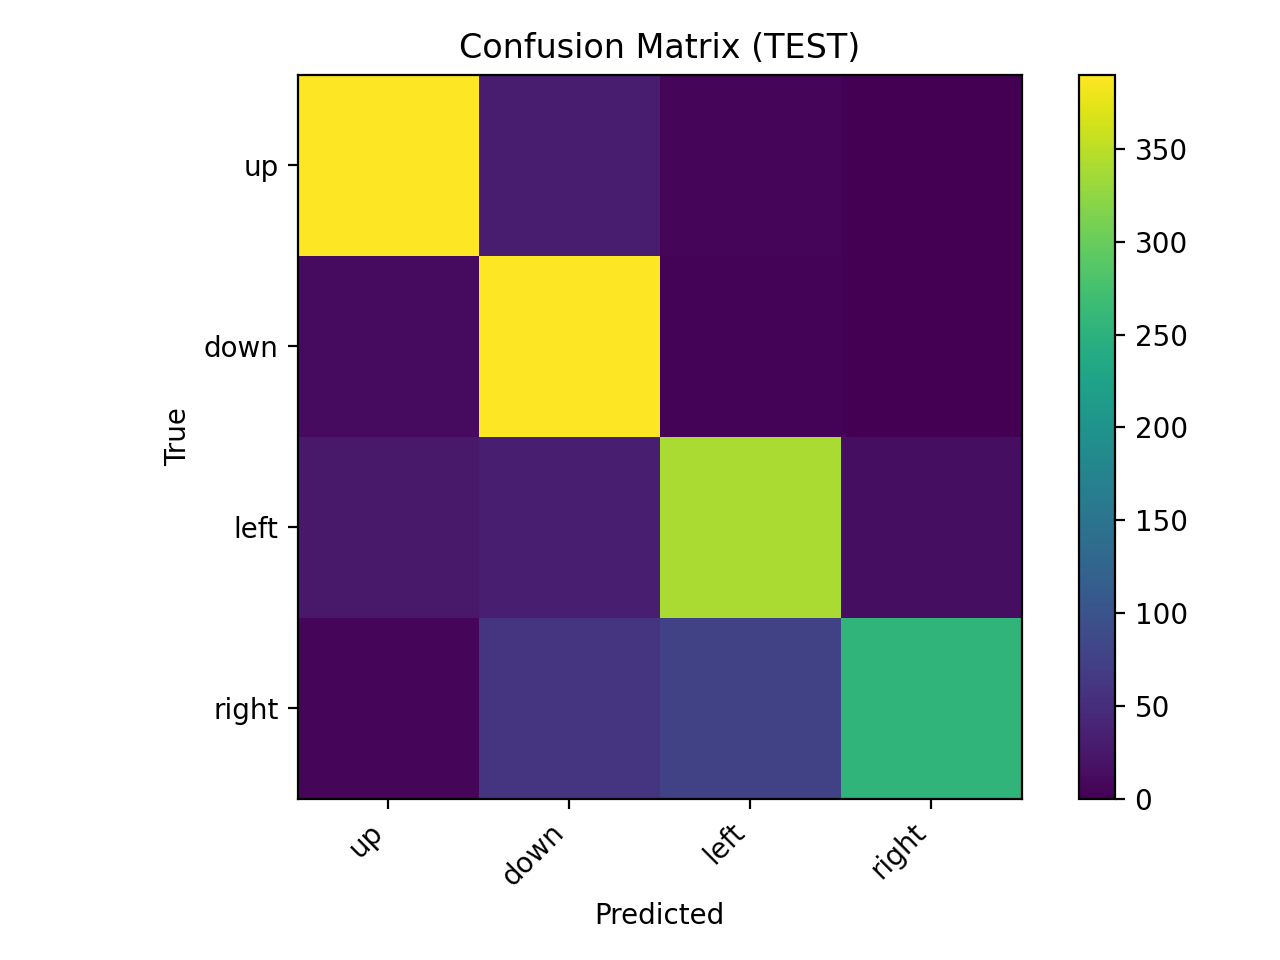

cnn_4class_baseline_1772452765_cm_val_0303.png


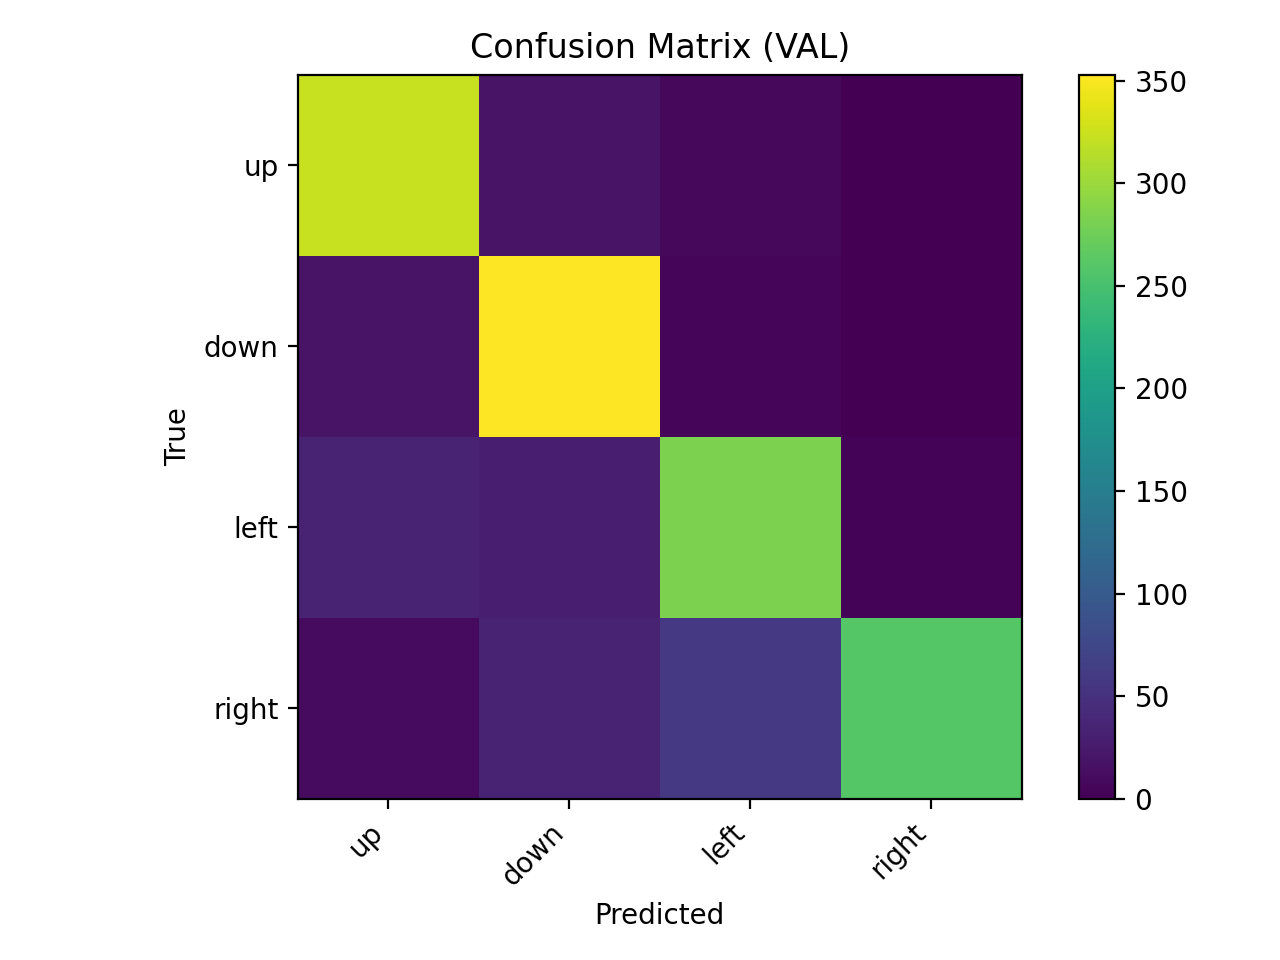

cnn_5class_weighted_1772453499_cm_test_0305.png


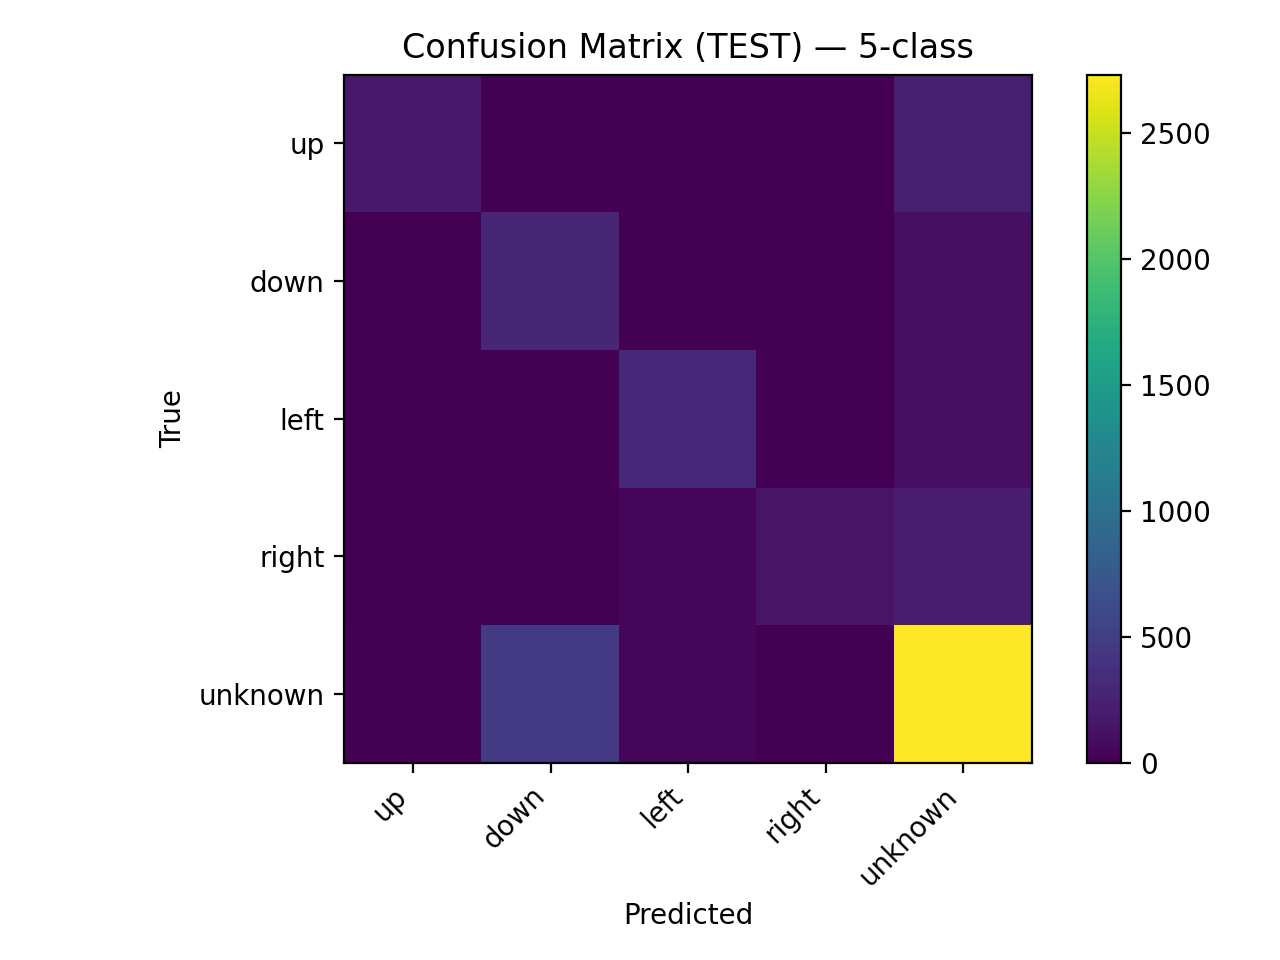

cnn_5class_weighted_1772453499_cm_val_0305.png


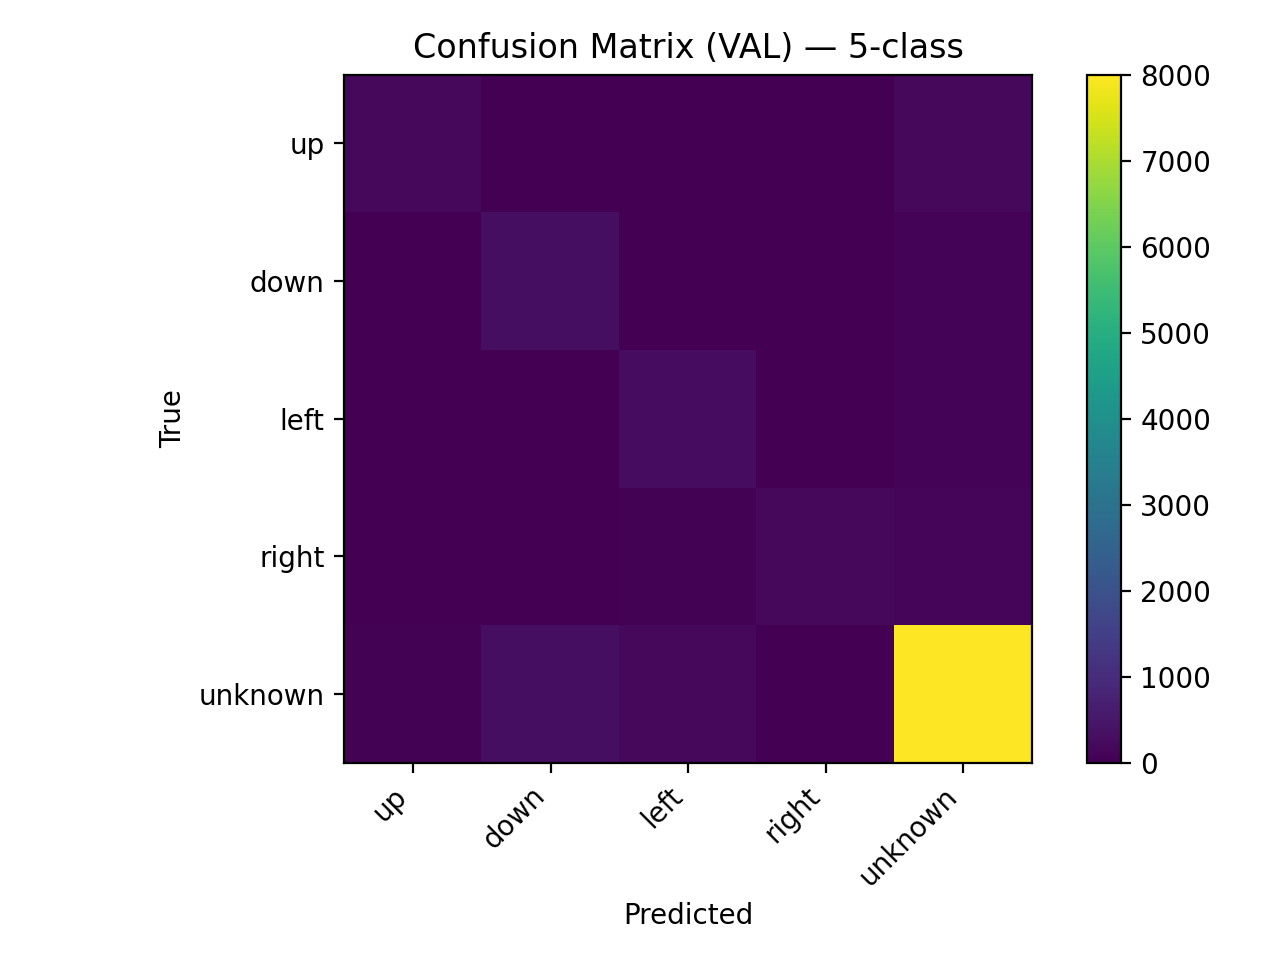

confusion_matrix_5class_E1_0602.png


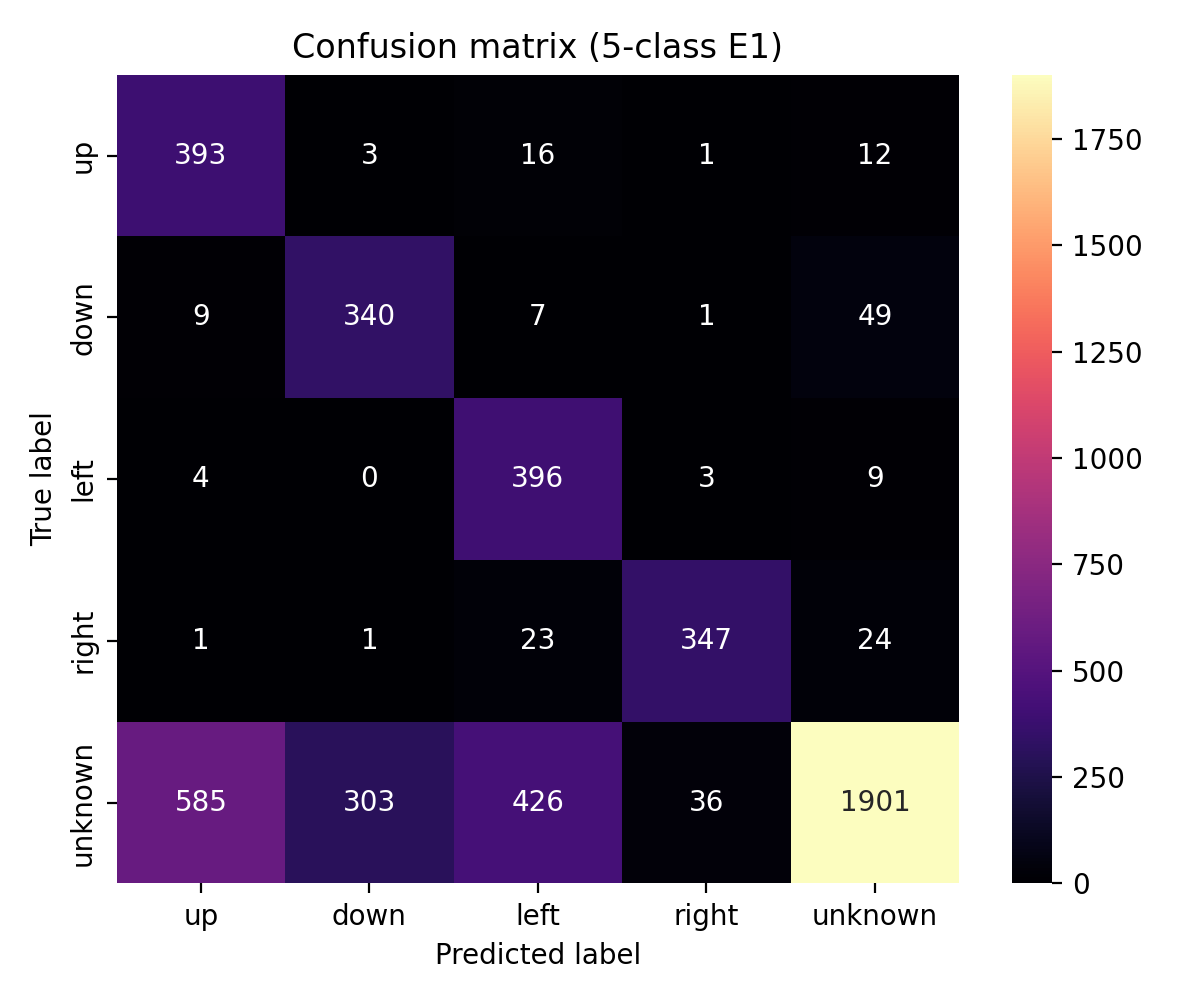

confusion_matrix_5class_E2_downsample_aug_0604.png


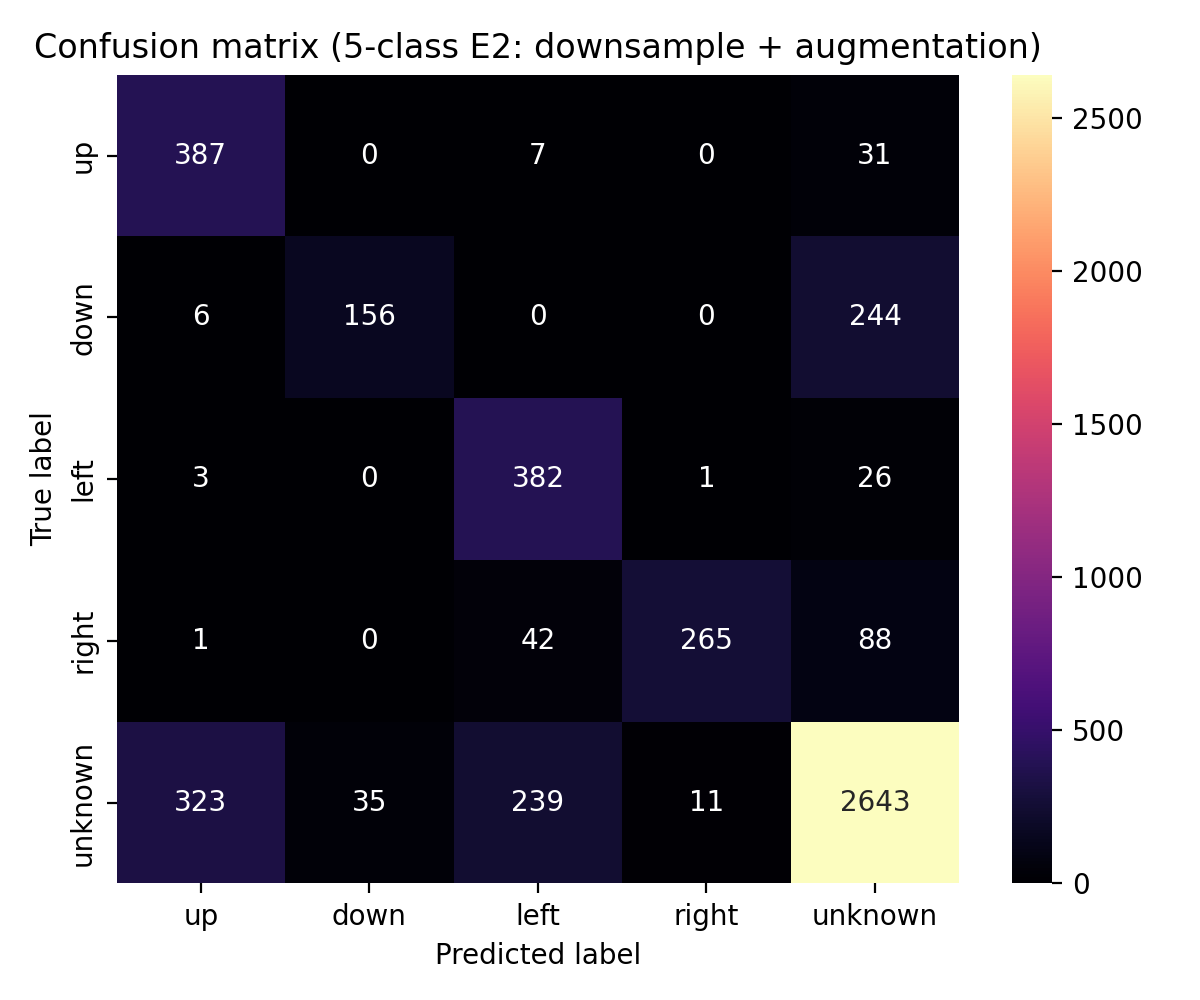

confusion_matrix_raw_waveform_conv1d_0703.png


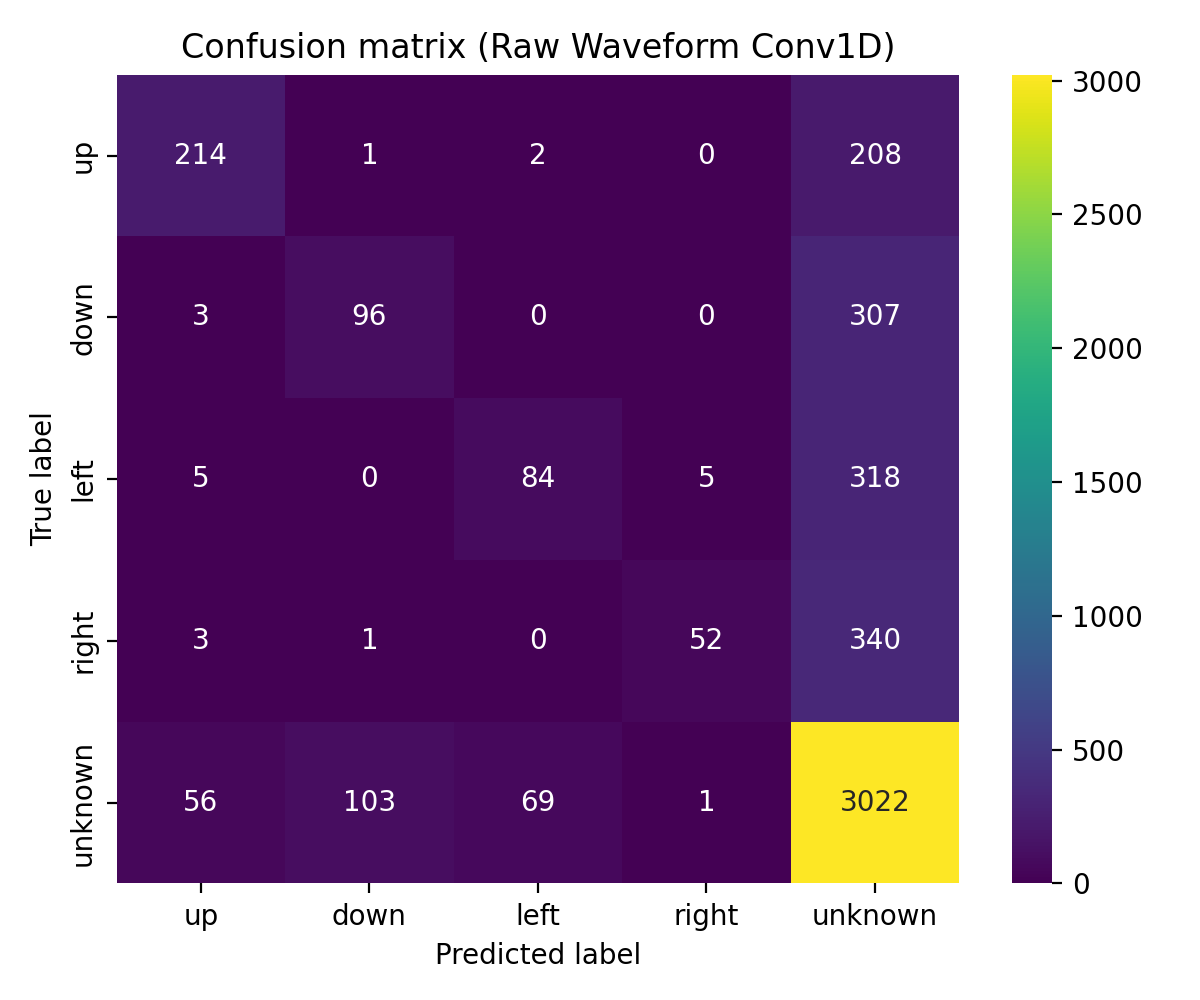

label_distribution_train_0104.png


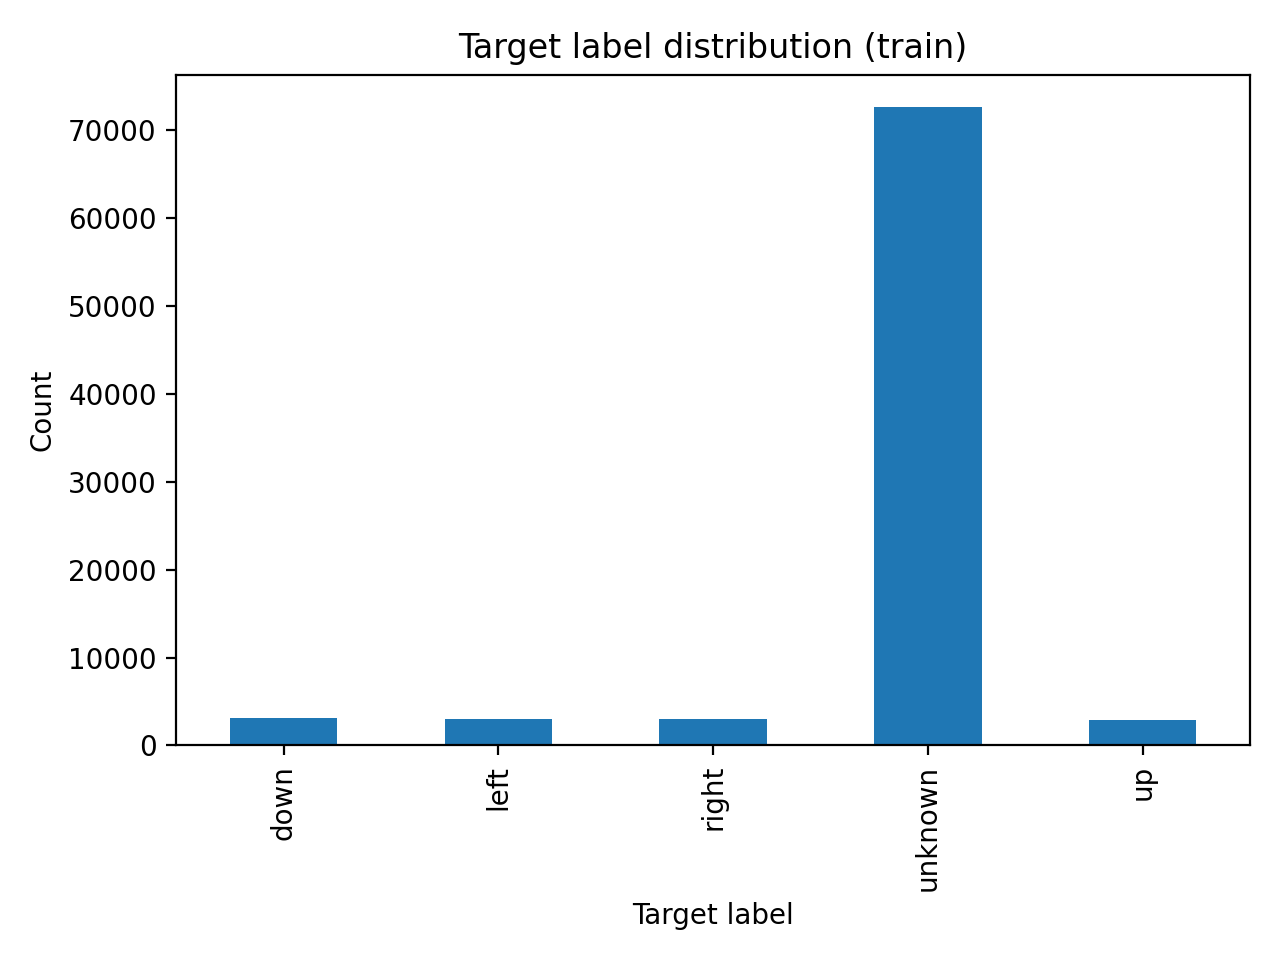

mel_spectrogram_example_0202.png


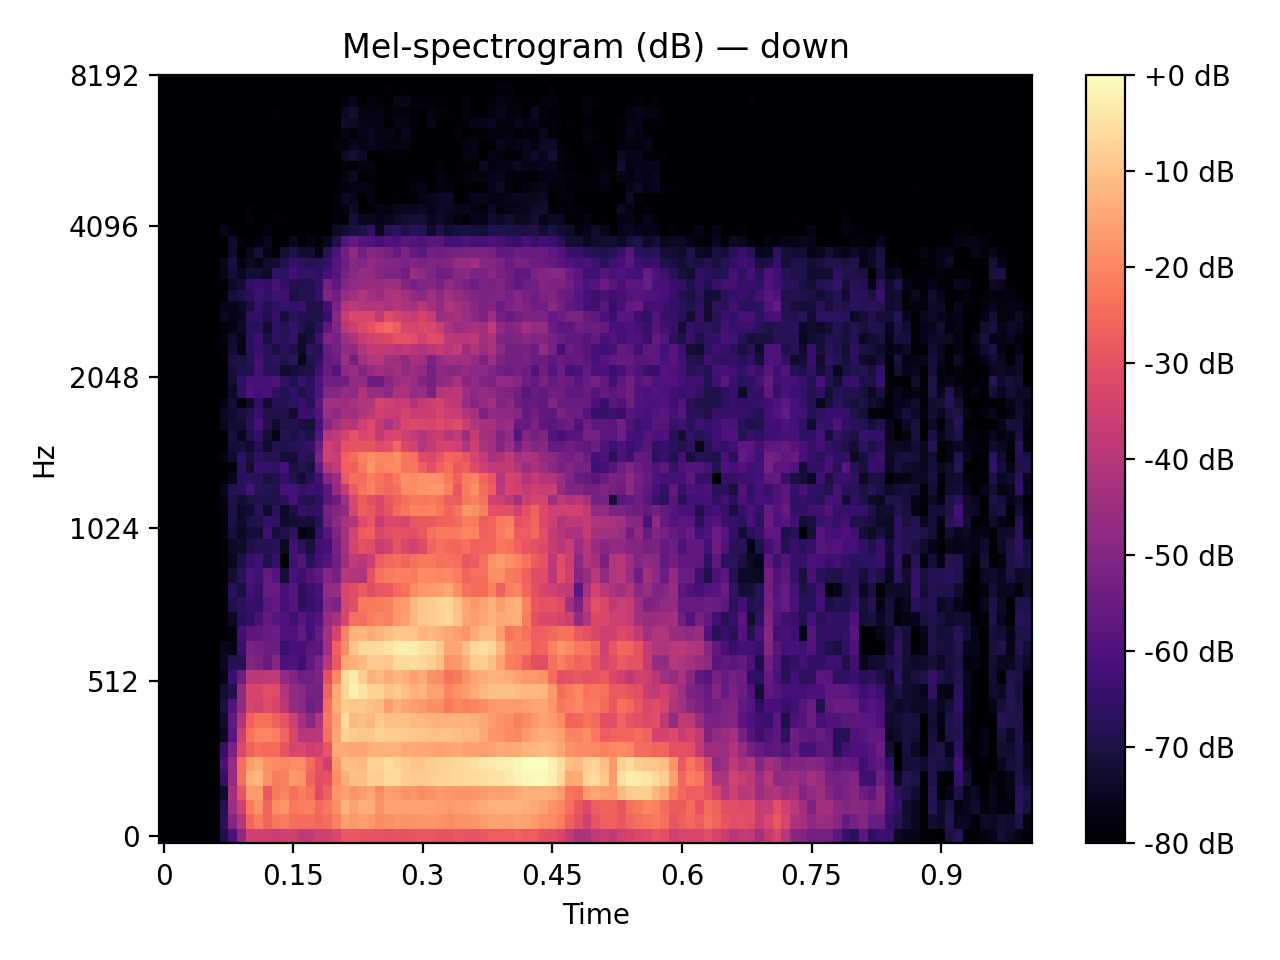

train_dist_5class_unknown_downsample_12000_0601.png


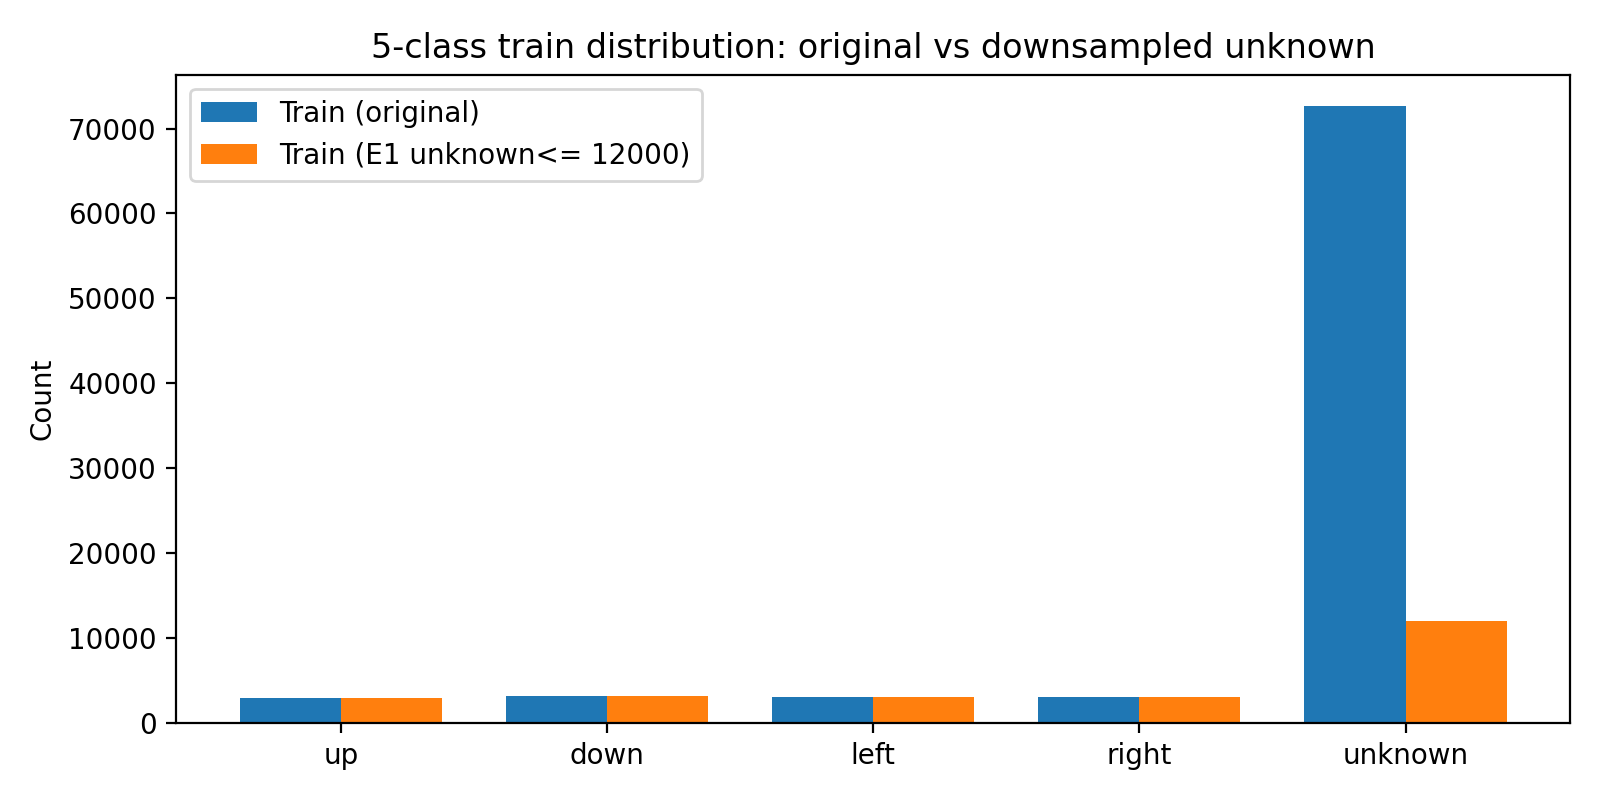

waveform_example_0202.png


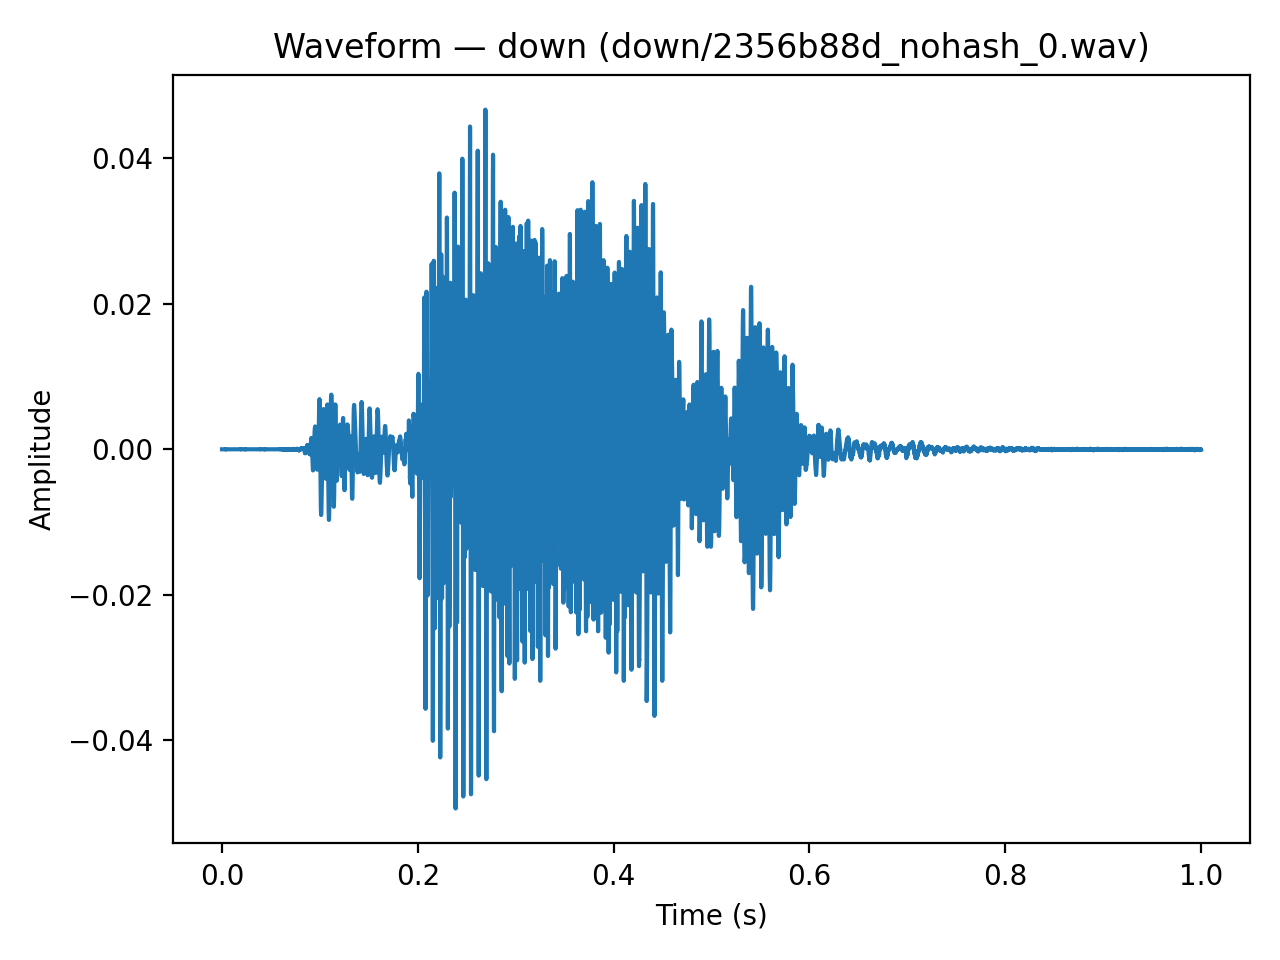

In [18]:
from IPython.display import display
from PIL import Image

for f in figure_files:
    print(Path(f).name)
    display(Image.open(f))

## 3. Prepare deployment files

#### Create deployment folder

In [19]:
deploy_dir = PROJECT_ROOT/"deployment"
deploy_dir.mkdir(parents=True, exist_ok=True)

print("Deployment dir:", deploy_dir)

Deployment dir: /content/drive/MyDrive/DAT255/voice-command-assistant/deployment


#### Make requirements.txt

In [20]:
requirements_txt = """gradio
torch
torchaudio
librosa
numpy
pandas
matplotlib
datasets
pillow
seaborn
"""

req_path = deploy_dir/"requirements.txt"
req_path.write_text(requirements_txt, encoding="utf-8")

print("Saved:", req_path)
print(req_path.read_text())

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/deployment/requirements.txt
gradio
torch
torchaudio
librosa
numpy
pandas
matplotlib
datasets
pillow
seaborn



#### Make app.py

In [21]:
app_py = r'''
import os
from pathlib import Path
import time
import numpy as np
import torch
import torch.nn as nn
import librosa
import gradio as gr

PROJECT_ROOT = Path(__file__).resolve().parent

SR = 16000
N_SAMPLES = 16000
N_MELS = 64
HOP_LENGTH = 160
N_FFT = 400

CLASS_NAMES = ["up", "down", "left", "right"]

class SmallSpectrogramCNN(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),

            nn.Flatten(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)

def pad_or_trim(x, n_samples=N_SAMPLES):
    x = x.astype(np.float32)
    if len(x) < n_samples:
        x = np.pad(x, (0, n_samples - len(x)), mode="constant")
    else:
        x = x[:n_samples]
    return x

def audio_to_mel_db(audio, sr):
    audio = audio.astype(np.float32)
    if sr != SR:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=SR)
    audio = pad_or_trim(audio, N_SAMPLES)

    S = librosa.feature.melspectrogram(
        y=audio,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmax=SR/2,
        power=2.0,
    )
    S_db = librosa.power_to_db(S, ref=np.max).astype(np.float32)
    return S_db

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SmallSpectrogramCNN(n_classes=4).to(device)

# Expect checkpoint file in same folder as app.py
ckpt_path = PROJECT_ROOT / "cnn_4class_best.pt"
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

@torch.no_grad()
def predict(audio_input):
    if audio_input is None:
        return "No audio provided.", 0.0, 0.0, 0.0, {}

    sr, audio = audio_input
    audio = audio.astype(np.float32)

    t0 = time.perf_counter()

    t_pre0 = time.perf_counter()
    S_db = audio_to_mel_db(audio, sr)
    t_pre1 = time.perf_counter()

    t_inf0 = time.perf_counter()
    X = torch.from_numpy(S_db).unsqueeze(0).unsqueeze(0).float().to(device)
    logits = model(X)
    probs = torch.softmax(logits, dim=1).detach().cpu().numpy().squeeze()
    t_inf1 = time.perf_counter()

    pred_id = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_id]
    confidence = float(probs[pred_id])

    preprocess_ms = (t_pre1 - t_pre0) * 1000.0
    inference_ms = (t_inf1 - t_inf0) * 1000.0
    total_ms = (time.perf_counter() - t0) * 1000.0

    prob_dict = {name: float(p) for name, p in zip(CLASS_NAMES, probs)}

    return pred_label, confidence, preprocess_ms, inference_ms, total_ms, prob_dict

demo = gr.Interface(
    fn=predict,
    inputs=gr.Audio(sources=["microphone", "upload"], type="numpy", label="Speak: up / down / left / right"),
    outputs=[
        gr.Label(label="Predicted command"),
        gr.Number(label="Confidence"),
        gr.Number(label="Preprocess latency (ms)"),
        gr.Number(label="Inference latency (ms)"),
        gr.Number(label="Total latency (ms)"),
        gr.JSON(label="Probabilities"),
    ],
    title="Voice Command Assistant",
    description="A small local speech command recognizer trained from scratch on Google Speech Commands.",
)

if __name__ == "__main__":
    demo.launch()
'''
app_path = deploy_dir/"app.py"
app_path.write_text(app_py, encoding="utf-8")

print("Saved:", app_path)

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/deployment/app.py


#### Copy best 4-class checkpoint to deployment folder

In [22]:
import shutil

models_dir = PROJECT_ROOT/"models"
ckpts = sorted(models_dir.glob("cnn_4class_baseline_*_best.pt"))
assert len(ckpts) > 0, "No 4-class checkpoints found."

src_ckpt = ckpts[-1]
dst_ckpt = deploy_dir/"cnn_4class_best.pt"

shutil.copy2(src_ckpt, dst_ckpt)

print("Copied checkpoint:")
print("From:", src_ckpt)
print("To:  ", dst_ckpt)

Copied checkpoint:
From: /content/drive/MyDrive/DAT255/voice-command-assistant/models/cnn_4class_baseline_1772452765_best.pt
To:   /content/drive/MyDrive/DAT255/voice-command-assistant/deployment/cnn_4class_best.pt


#### Make README for deployment

In [23]:
readme_md = """# Voice Command Assistant

This is a small speech command recognizer trained from scratch on the Google Speech Commands dataset.

## Supported commands
- up
- down
- left
- right

## Model
The deployed model is a small spectrogram-based CNN trained from scratch in PyTorch.

## Features
- microphone input
- file upload
- class probabilities
- latency breakdown

## Project context
This project was developed for DAT255 Deep Learning Engineering.

"""
readme_path = deploy_dir/"README.md"
readme_path.write_text(readme_md, encoding="utf-8")

print("Saved:", readme_path)
print(readme_path.read_text())

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/deployment/README.md
# Voice Command Assistant

This is a small speech command recognizer trained from scratch on the Google Speech Commands dataset.

## Supported commands
- up
- down
- left
- right

## Model
The deployed model is a small spectrogram-based CNN trained from scratch in PyTorch.

## Features
- microphone input
- file upload
- class probabilities
- latency breakdown

## Project context
This project was developed for DAT255 Deep Learning Engineering.




#### Show what is ready for deployment

In [24]:
print("Deployment files:")
for p in sorted(deploy_dir.iterdir()):
    print("-", p.name)

Deployment files:
- README.md
- app.py
- cnn_4class_best.pt
- requirements.txt
